# Lab: Data exploration

---

<a id="learning-objectives"></a>
## Learning Objectives
*After completing this lab, you will be able to:*

- Explore and interrogate different data sets using our pandas and matplotlib.
- Interpret the findings to understand what the data tells us about the real world.

<a id="coffee"></a>

# <font color='blue'> Coffee shop data</font>

## Part A

In this Lab we'll be working with one datasets.
    
The dataset consists of coffee shop transactions, a dataset created by IBM and made available on [Kaggle](https://www.kaggle.com/datasets/ylchang/coffee-shop-sample-data-1113).

The data consists of coffee shop transactions in April 2019.

There are ~50,000 total transactions in the data set. The data consists of transactions from shops in New York City only.

Our task is to answer 3 questions:
1. **Which products offer the best margins?**
2. **Are particular customer groups spending more?**
3. **Which products generate the most sales?**

<br />

Let's start by reading in the data as a pandas `DataFrame` called `coffee_df`.

In [88]:
# Importing needed library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 1.❓ Next, let's read in the data as a pandas `DataFrame` called `coffee_df`

In [89]:
coffee_df = pd.read_csv('./Data./coffee_shop_lab.csv')

##### 2.❓Now preview the first 5 rows of the data.

In [90]:
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials


##### 3.❓ How many rows and columns does the dataset have?

In [91]:
coffee_df.shape


(49894, 13)

##### 4.❓ Check the type of data in each column- do you notice any problems?

In [92]:
coffee_df.dtypes #data,customer_since and time are object

transaction_date            object
transaction_time            object
customer_id                float64
quantity                     int64
line_item_amount           float64
unit_price                 float64
product_group               object
product_category            object
product_type                object
current_wholesale_price    float64
customer_since              object
customer_birth_year        float64
customer_generation         object
dtype: object

> 👉 **Write Your Findings Here**: 
-- -

##### 5.❓ You might have noticed earlier when running the `dtypes` command that the `transaction_date` and `customer_since` columns are currently being treated like strings. We need to convert them into date columns so we can calculate factors like how long someone's been a customer.

Try using pd.to_datetime() to convert these two columns to date representations

In [93]:
pd.to_datetime(coffee_df['transaction_date']) 
pd.to_datetime(coffee_df['customer_since']) 



0       2018-06-19
1       2017-03-03
2       2019-01-14
3       2017-08-11
4       2018-05-06
           ...    
49889   2017-01-08
49890   2017-04-08
49891          NaT
49892   2017-06-26
49893   2017-06-29
Name: customer_since, Length: 49894, dtype: datetime64[ns]

##### 6.❓ Examine the percentage of missing values in each column. What might these missing values represent? How would you suggest handling them?



In [94]:

coffee_missing = (coffee_df.isnull().sum() / len(coffee_df)) * 100
print(coffee_missing)

transaction_date            0.000000
transaction_time            0.000000
customer_id                50.172365
quantity                    0.000000
line_item_amount            0.000000
unit_price                  0.000000
product_group               0.000000
product_category            0.000000
product_type                0.000000
current_wholesale_price     0.000000
customer_since             50.190404
customer_birth_year        50.190404
customer_generation        50.190404
dtype: float64


👉 Since more than 50% of the customer-related data is missing

👉 The missing values in the customer-related columns of your coffee dataset could represent:

- Guest Customers 
- Incomplete Data Collection 
- Data Integration Issues
  

👉 Is the missing values essentials to your analysis? 
- If necessary:
    - consider finding the missing values
    - Or, create a dataset that contains the rows that have filled information and discard the rows that have null values for that customer-related columns.

- If not necessary in your analysis, just ignore them

##### 7.❓ Check for duplicate values, and remove them if any.

In [95]:
# how many duplicates we have
coffee_df.duplicated().sum()


149

In [96]:
# Remove the duplicates and check if the total duplicates is 0 now
coffee_df = coffee_df.drop_duplicates()
coffee_df.duplicated().sum()


0

##### 8.❓ Explore the unique values in all the categorical columns:
- product group
- product category
- product type
- customer_generation

1. What inconsistencies do you notice?
2. Is there a spelling consistency?
3. Do you need to fix anything?

In [97]:
# unique values in product group
coffee_df['product_group'].unique()


array(['Beverages', 'Food', 'Whole Bean/Teas', 'Add-ons', 'Merchandise'],
      dtype=object)

In [98]:
# unique values in product category
coffee_df['product_category'].unique()


array(['Tea', 'Coffee', 'Drinking Chocolate', 'Bakery', 'Coffee beans',
       'Flavours', 'Loose Tea', 'Packaged Chocolate', 'Branded'],
      dtype=object)

In [99]:
# unique values in product type
coffee_df['product_type'].unique()


array(['Brewed Chai tea', 'Organic brewed coffee', 'Brewed Green tea',
       'Drip coffee', 'Premium brewed coffee', 'Gourmet brewed coffee',
       'Brewed Black tea', 'Hot chocolate', 'Barista Espresso', 'Scone',
       'Brewed herbal tea', 'Biscotti', 'Pastry', 'Organic Beans',
       'Regular syrup', 'Herbal tea', 'Gourmet Beans', 'Black tea',
       'Sugar free syrup', 'House blend Beans', 'Premium Beans',
       'Chai tea', 'Organic Chocolate', 'Drinking Chocolate',
       'Green beans', 'Green tea', 'Espresso Beans', 'Housewares',
       'Clothing'], dtype=object)

In [100]:
# unique values in customer_generation

coffee_df['customer_generation'].unique()

array(['Older Millennials', 'Baby Boomers', 'Gen Z', 'Gen X',
       'Younger Millennials', nan], dtype=object)

##### 9.❓The `describe()` method is a handy way of accessing summary statistics for an entire `DataFrame` in one go. Try running it on your `DataFrame`:


In [101]:

coffee_df.describe()

,customer_id,quantity,line_item_amount,unit_price,current_wholesale_price,customer_birth_year
count,24801.000000,49745.000000,49745.000000,49745.000000,49745.000000,24792.000000
mean,4582.647837,1.439481,4.687731,3.384018,1.354957,1978.248871
std,3247.554091,0.543316,4.441833,2.686402,2.204466,15.088333
min,1.000000,1.000000,0.000000,0.800000,0.040000,1950.000000
25%,584.000000,1.000000,3.000000,2.500000,0.600000,1965.000000
50%,5417.000000,1.000000,3.750000,3.000000,0.750000,1981.000000
75%,8099.000000,2.000000,6.000000,3.750000,1.950000,1992.000000
max,8501.000000,8.000000,360.000000,45.000000,36.000000,2001.000000


##### 10.❓What is your findings about the above summery statistics?

> Write your findings here:

👉 The `line_item_amount` column has a minimum value of 0, which seems unusual. This could indicate potential error values.

👉 The quantity column appears to be right-skewed, with 75% of orders containing only two products, while the maximum quantity is 8.

- Let's start to clean up our dataset and answer the questions in our analysis.

- We have the total line item amount (the retail price) as well as the wholesale price of the product.

- We want to calculate the **total wholesale line item amount** so we can use it to calculate profit.

##### 11.❓Can you combine the existing wholesale amount and quantity columns to create a new column in the `DataFrame` called `total_wholesale_amount` which holds the new values?

In [102]:
coffee_df['total_wholesale_amount']=coffee_df['current_wholesale_price']*coffee_df['quantity']
coffee_df

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount
0,2019-04-01,12:04:43,558.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63
1,2019-04-01,11:15:38,22.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63
2,2019-04-01,12:05:31,659.0,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26
3,2019-04-01,16:49:38,407.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63
4,2019-04-01,19:17:34,537.0,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49889,2019-04-24,09:31:54,8113.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z,7.16
49890,2019-04-25,06:17:12,5778.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers,7.16
49891,2019-04-25,10:48:21,NaN,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaN,NaN,NaN,7.16
49892,2019-04-25,08:54:27,8039.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers,7.16


##### 12.❓Can you now create a new column called `profit` which shows the difference between the wholesale price and retail price(line_item_amount)?

In [103]:
coffee_df['profit']=coffee_df['current_wholesale_price']*coffee_df['line_item_amount']
coffee_df

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit
0,2019-04-01,12:04:43,558.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.575
1,2019-04-01,11:15:38,22.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.575
2,2019-04-01,12:05:31,659.0,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.150
3,2019-04-01,16:49:38,407.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.575
4,2019-04-01,19:17:34,537.0,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49889,2019-04-24,09:31:54,8113.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z,7.16,64.082
49890,2019-04-25,06:17:12,5778.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers,7.16,64.082
49891,2019-04-25,10:48:21,NaN,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaN,NaN,NaN,7.16,64.082
49892,2019-04-25,08:54:27,8039.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers,7.16,64.082


##### 13.❓Find the highest sale price in the dataset.

In [104]:
highest_sale_price = coffee_df['line_item_amount'].max()
highest_sale_price

360.0

##### 14.❓Find the largest amount of profit.

In [105]:
largest_profit = coffee_df['profit'].max()
largest_profit

12960.0

The largest profit is significant - but it's obviously not representative of how much profit is made on each transaction on average.

##### 15.❓Find the mean of all the profit.

In [106]:
largest_profit = coffee_df['profit'].mean()
largest_profit


12.207768061111672

##### 16.❓Now, let's start filtering our data by writing logical tests. How many transactions were valued above the **mean** transaction amount? 

In [107]:
# 1. Calculate the mean transaction amount
mean_amount = coffee_df['line_item_amount'].mean()
transactions_above_mean = coffee_df[coffee_df['line_item_amount'] > mean_amount]
count_above_mean = len(transactions_above_mean)

print(f"Number of transactions valued above the mean: {count_above_mean}")


Number of transactions valued above the mean: 19544


##### 17.❓Create a new column called `profit_ratio` which shows the ratio between the wholesale and retail prices.  

In [108]:
coffee_df['profit_ratio']=coffee_df['current_wholesale_price']/coffee_df['line_item_amount']
coffee_df


,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
0,2019-04-01,12:04:43,558.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.575,0.252
1,2019-04-01,11:15:38,22.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.575,0.252
2,2019-04-01,12:05:31,659.0,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.150,0.126
3,2019-04-01,16:49:38,407.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.575,0.252
4,2019-04-01,19:17:34,537.0,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.150,0.126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49889,2019-04-24,09:31:54,8113.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z,7.16,64.082,0.800
49890,2019-04-25,06:17:12,5778.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers,7.16,64.082,0.800
49891,2019-04-25,10:48:21,NaN,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaN,NaN,NaN,7.16,64.082,0.800
49892,2019-04-25,08:54:27,8039.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers,7.16,64.082,0.800


##### 18.❓Based on profit ratio, How many transactions made a profit of at least 2 times their wholesale cost?

In [109]:
transactions = coffee_df[coffee_df['profit_ratio'] >= 3]
count_transactions = len(transactions)
count_transactions

24

##### 19.❓How many transactions in the dataset were for coffee `beans`? You'll have to think creatively about where this information is stored in the dataset, and how to extract it.

In [110]:
# Filter for rows where the product group is 'Whole Bean/Teas' 
# AND the product type or category contains the word 'Coffee' (ignoring case)
bean_transactions = coffee_df[
    (coffee_df['product_group'] == 'Whole Bean/Teas') & 
    (coffee_df['product_category'].str.contains('Coffee', case=False, na=False) | 
     coffee_df['product_type'].str.contains('Bean', case=False, na=False))
]

# Count the results
coffee_beans_count = len(bean_transactions)
print(f"Number of transactions for coffee beans: {coffee_beans_count}")

Number of transactions for coffee beans: 587


##### 20.❓Sort the dataset in descending order of profit, to find the transaction that generated the highest profit.

In [114]:
coffee_df_sorted=coffee_df['profit_ratio'].sort_values(ascending=False)
coffee_df_sorted.head(1)

45305    inf
Name: profit_ratio, dtype: float64

##### 21.❓Did any transactions make a loss where the profit is less than 0?


In [117]:
loss_transactions_count = (coffee_df['line_item_amount'] < 0).sum()
loss_transactions_count

0

- Look at the above result of transactions that made loss.
You might notice some oddities when answering this question. Are all the rows you identified genuine losses or data errors?
* Hint: is there anything that does not show the correct result of line_item_amount?
* Note: line_item_amount = unit_price * quantity


##### Write your findindg here please:
- No loss

##### 22.❓Correct the line item amount column with the correct values

In [119]:
coffee_df['line_item_amount'] = coffee_df['unit_price'] * coffee_df['quantity']

coffee_df[['quantity', 'unit_price', 'line_item_amount']].head()


,quantity,unit_price,line_item_amount
0,1,2.5,2.5
1,1,2.5,2.5
2,2,2.5,5.0
3,1,2.5,2.5
4,2,2.5,5.0


##### 23.❓Re-calculate the profit column that you did earlier to fix the profit value after you corrected the line_item_amount column you did in the previous step

In [120]:
coffee_df['profit'] = coffee_df['line_item_amount'] - (coffee_df['current_wholesale_price'] * coffee_df['quantity'])
coffee_df[['quantity', 'unit_price', 'line_item_amount', 'current_wholesale_price', 'profit']].head()

,quantity,unit_price,line_item_amount,current_wholesale_price,profit
0,1,2.5,2.5,0.63,1.87
1,1,2.5,2.5,0.63,1.87
2,2,2.5,5.0,0.63,3.74
3,1,2.5,2.5,0.63,1.87
4,2,2.5,5.0,0.63,3.74


##### 24.❓Re-check the transactions that make a loss where the profit is less than 0?

In [121]:
loss_transactions_count = (coffee_df['profit'] < 0).sum()
loss_transactions_count


2

##### How many transactions made loss?
- Only two transactions are having loss on profit

##### 25.❓How many transactions were for each product group categories in the dataset?



In [122]:
product_group_counts = coffee_df['product_group'].value_counts()
product_group_counts

product_group
Beverages          38592
Food                7521
Add-ons             2248
Whole Bean/Teas     1139
Merchandise          245
Name: count, dtype: int64

##### 26.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

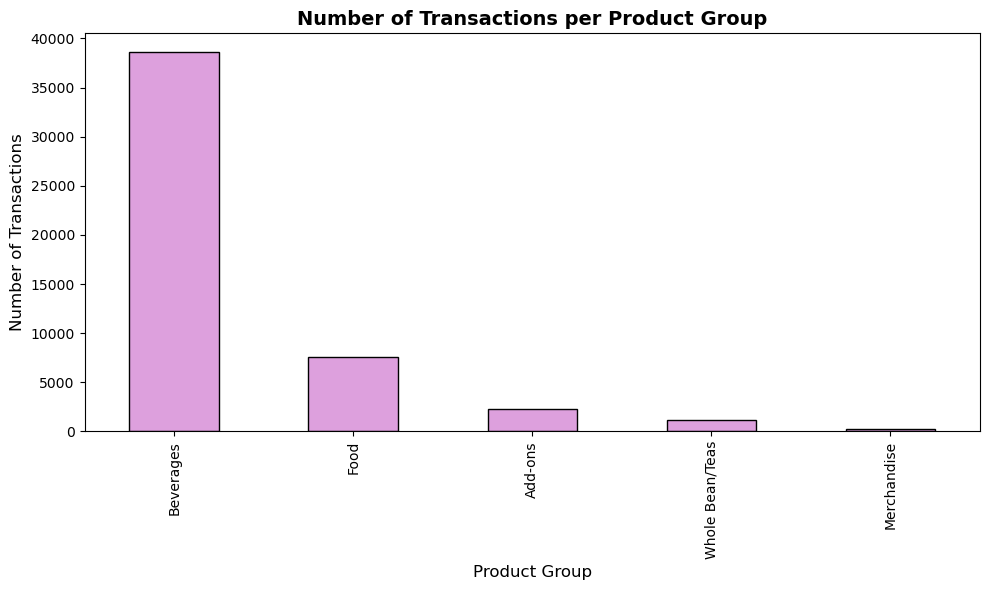

In [130]:
plt.figure(figsize=(10, 6)) 
product_group_counts.plot(kind='bar', color='plum', edgecolor='black')
plt.title('Number of Transactions per Product Group', fontsize=14, fontweight='bold')
plt.xlabel('Product Group', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.tight_layout()
plt.show()

##### 27.❓Can you calculate the median profit for each product type?

In [131]:
median_profit_per_type = coffee_df.groupby('product_type')['profit'].median()
median_profit_per_type

product_type
Barista Espresso          3.40
Biscotti                  1.22
Black tea                 1.79
Brewed Black tea          3.74
Brewed Chai tea           3.74
Brewed Green tea          3.74
Brewed herbal tea         3.74
Chai tea                  1.90
Clothing                 19.04
Drinking Chocolate        2.67
Drip coffee               2.40
Espresso Beans            2.95
Gourmet Beans             4.20
Gourmet brewed coffee     3.20
Green beans               2.00
Green tea                 1.85
Herbal tea                1.79
Hot chocolate             1.74
House blend Beans         3.60
Housewares                9.52
Organic Beans             3.60
Organic Chocolate         1.52
Organic brewed coffee     3.52
Pastry                    1.31
Premium Beans             9.00
Premium brewed coffee     3.92
Regular syrup             1.52
Scone                     1.14
Sugar free syrup          1.52
Name: profit, dtype: float64

##### 28.❓Create a column that shows the transaction_day



In [132]:
coffee_df['transaction_date'] = pd.to_datetime(coffee_df['transaction_date'])
coffee_df['transaction_day'] = coffee_df['transaction_date'].dt.day_name()
coffee_df[['transaction_date', 'transaction_day']].head()

,transaction_date,transaction_day
0,2019-04-01,Monday
1,2019-04-01,Monday
2,2019-04-01,Monday
3,2019-04-01,Monday
4,2019-04-01,Monday


##### 29.❓Is there a relationship between the day of the week and the total sale revenue? How could you explain any relationship you can see in the data?
*hint*: total sale revenue is the line_item_amount column

In [135]:
revenue_per_day = coffee_df.groupby('transaction_day')['line_item_amount'].sum().reindex(days_order)
revenue_per_day


transaction_day
Monday       39563.74
Tuesday      32371.81
Wednesday    34374.03
Thursday     31902.82
Friday       32304.55
Saturday     32138.85
Sunday       31014.75
Name: line_item_amount, dtype: float64

##### 30.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

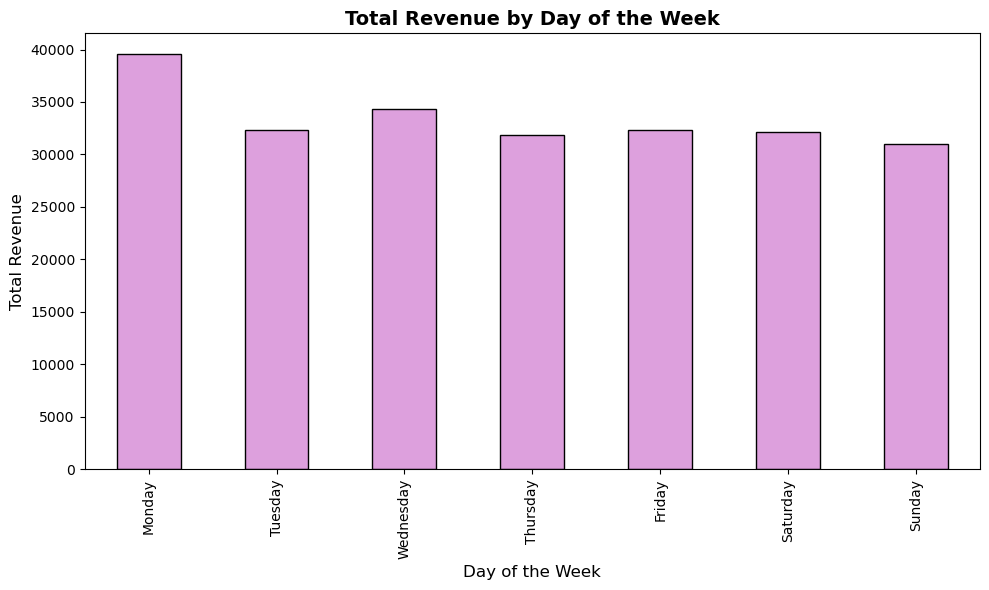

In [136]:
plt.figure(figsize=(10, 6)) 
revenue_per_day.plot(kind='bar', color='plum', edgecolor='black')
plt.title('Total Revenue by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.tight_layout()
plt.show()

##### Write your findings here please:
👉 More transactions on Monday suggest a "back to work blues" effect

##### 31.❓The client suspects that the Gen Z customer cohort spends the most. Can you test this out and confirm whether it's true or not? not

In [139]:
generation_spend = coffee_df.groupby('customer_generation')['line_item_amount'].sum().sort_values(ascending=False)
generation_spend

customer_generation
Baby Boomers           27295.04
Gen X                  26739.61
Older Millennials      25166.90
Gen Z                  19716.40
Younger Millennials    15414.78
Name: line_item_amount, dtype: float64

##### 32.❓Prove previous step by plotting a bar chart

_🎨 Visualize your results 🎨_

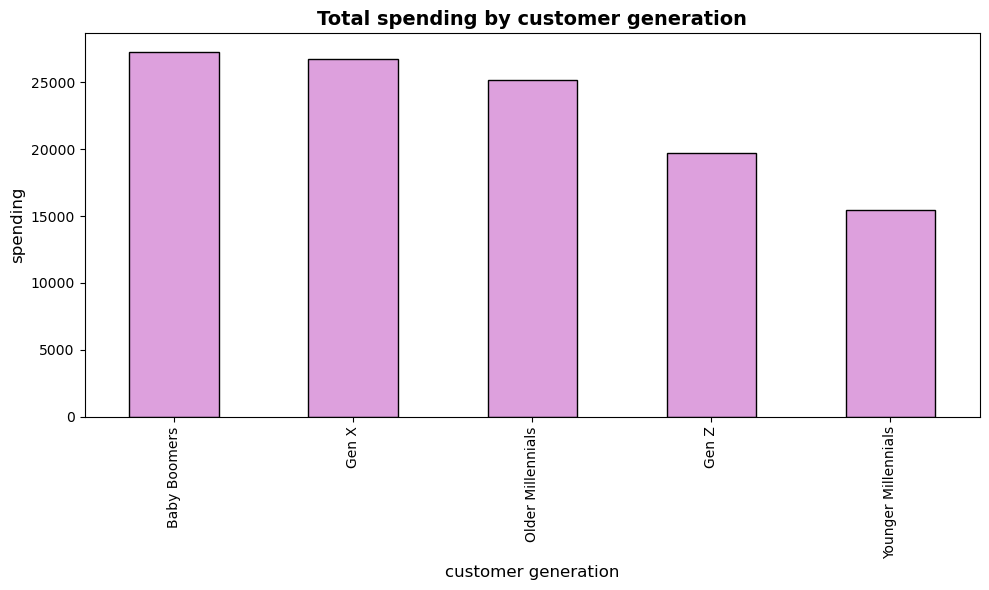

In [142]:
plt.figure(figsize=(10, 6)) 
generation_spend.plot(kind='bar', color='plum', edgecolor='black')
plt.title('Total spending by customer generation', fontsize=14, fontweight='bold')
plt.xlabel('customer generation', fontsize=12)
plt.ylabel('spending', fontsize=12)
plt.tight_layout()
plt.show()


##### 33.❓ Is GenZ spend the most as suspected? 
##### Write your findings here please:

👉 It looks like the opposite, Gen Z spend the second lowest in total.
-- -

## Part B 
In this section explore the coffee shop data to answer the following questions : 
1. **What kinds of products type generate the most profit? show top 5 only. Plot a chart to show the result**
2. **What segment of customers generate the most profit ratio? Plot a chart to show the result**


##### 1.❓What kinds of products type generate the most profit? show top 5 only


In [147]:
profitable_products = coffee_df.groupby('product_type')['profit'].sum().sort_values(ascending=False).head(5)
profitable_products


product_type
Barista Espresso         24510.50
Brewed Chai tea          19224.25
Gourmet brewed coffee    18944.72
Brewed Black tea         11950.33
Brewed herbal tea        11829.56
Name: profit, dtype: float64

##### 2.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

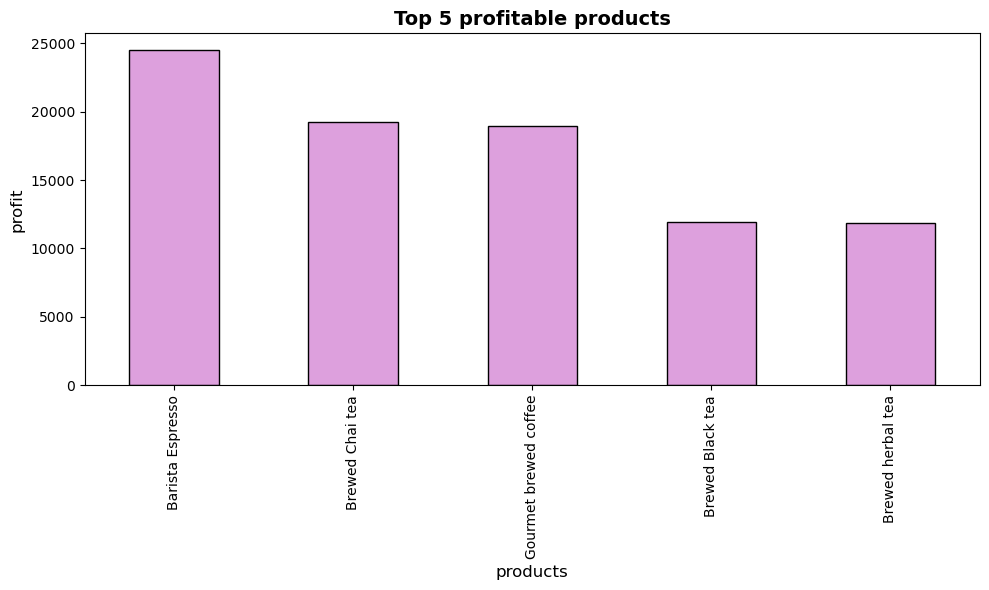

In [149]:
plt.figure(figsize=(10, 6)) 
profitable_products.plot(kind='bar', color='plum', edgecolor='black')
plt.title('Top 5 profitable products', fontsize=14, fontweight='bold')
plt.xlabel('products', fontsize=12)
plt.ylabel('profit', fontsize=12)
plt.tight_layout()
plt.show()

##### 3.❓What segment of customers generate the most profit ratio? 

*Hint*: Show the average of profit ratio

In [153]:
customer_segments = coffee_df.groupby('customer_generation').agg(
    total_profit=('profit', 'sum'),
    total_sales=('line_item_amount', 'sum')
)
customer_segments['profit_ratio'] = customer_segments['total_profit'] / customer_segments['total_sales']
customer_segments_sorted = customer_segments.sort_values(by='profit_ratio', ascending=False)
customer_segments_sorted

,total_profit,total_sales,profit_ratio
customer_generation,,,
Younger Millennials,9877.56,15414.78,0.640785
Older Millennials,16093.98,25166.90,0.639490
Baby Boomers,17396.06,27295.04,0.637334
Gen Z,12545.02,19716.40,0.636273
Gen X,16789.98,26739.61,0.627907


##### 4.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

<Figure size 1000x600 with 0 Axes>

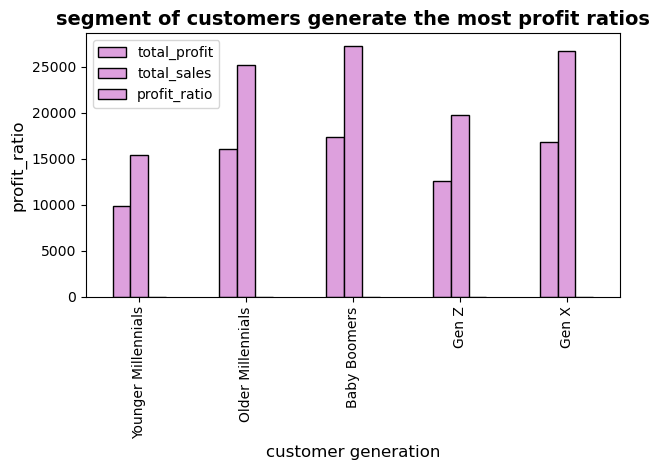

In [156]:
plt.figure(figsize=(10, 6)) 
customer_segments_sorted.plot(kind='bar', color='plum', edgecolor='black')
plt.title('segment of customers generate the most profit ratios', fontsize=14, fontweight='bold')
plt.xlabel('customer generation', fontsize=12)
plt.ylabel('profit_ratio', fontsize=12)
plt.tight_layout()
plt.show()



## Part C : Dig Deeper

In this section you are going to be doing your own analysis to answer this 3 main questions :
##### 1.❓Are there better or worse days/times in terms of sales? Plot a chart to show the result

In [161]:
# Extracting dates from transaction date

coffee_df['transaction_date'] = pd.to_datetime(coffee_df['transaction_date'])
coffee_df['transaction_date']

0       2019-04-01
1       2019-04-01
2       2019-04-01
3       2019-04-01
4       2019-04-01
           ...    
49889   2019-04-24
49890   2019-04-25
49891   2019-04-25
49892   2019-04-25
49893   2019-04-25
Name: transaction_date, Length: 49745, dtype: datetime64[ns]

In [169]:
# Creating time categories function to return Morning, Noon, Evenging, Night based on transaction_time
coffee_df['transaction_hour'] = pd.to_datetime(coffee_df['transaction_time'], format='%H:%M:%S').dt.hour

def get_time_category(hour):
    if 5 <= hour < 12:
        return 'Morning'    
    elif 12 <= hour < 17:
        return 'Noon'      
    elif 17 <= hour < 21:
        return 'Evening'    
    else:
        return 'Night'    

# use apply to apply the time category into a new column called time_category
coffee_df['time_category'] = coffee_df['transaction_hour'].apply(get_time_category)
coffee_df[['transaction_time', 'transaction_hour', 'time_category']].head()


,transaction_time,transaction_hour,time_category
0,12:04:43,12,Noon
1,11:15:38,11,Morning
2,12:05:31,12,Noon
3,16:49:38,16,Noon
4,19:17:34,19,Evening


In [165]:
# Are there better or worse days/times in terms of sales?
coffee_df.groupby('time_category')['line_item_amount'].sum().sort_values(ascending=False)
# Write your findings

time_category
Morning    128536.97
Noon        68893.76
Evening     35714.29
Night         525.53
Name: line_item_amount, dtype: float64

> 👉 **Write Your Findings Here**: 
-- - Morning is the more active time

##### 2.❓Does customers’ willingness to pay for `Beverages` product group vary by generation? Plot a chart to show the result

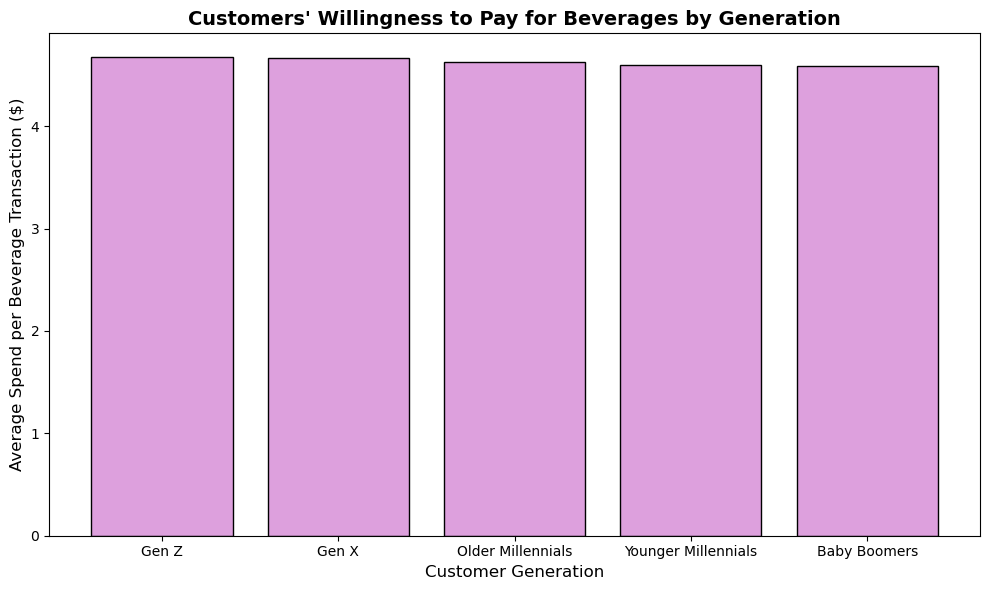

In [167]:
# Does customers’ willingness to pay for Beverages vary by generation?

beverages_df = coffee_df[coffee_df['product_group'] == 'Beverages']
generation_wtp = beverages_df.groupby('customer_generation')['line_item_amount'].mean().sort_values(ascending=False).reset_index()
generation_wtp

plt.figure(figsize=(10, 6))
plt.bar(generation_wtp['customer_generation'], generation_wtp['line_item_amount'], color='plum', edgecolor='black')
plt.title("Customers' Willingness to Pay for Beverages by Generation", fontsize=14, fontweight='bold')
plt.xlabel('Customer Generation', fontsize=12)
plt.ylabel('Average Spend per Beverage Transaction', fontsize=12)
plt.tight_layout()
plt.show()

# Write your findings

> 👉 **Write Your Findings Here**: 
-- - The Average Spend per Beverage Transaction is the same for all generation

##### 3.❓Do customers who have been customers longer tend to spend more? Plot a chart to show the result (Hint : You may need to use date.today() to get todays date)

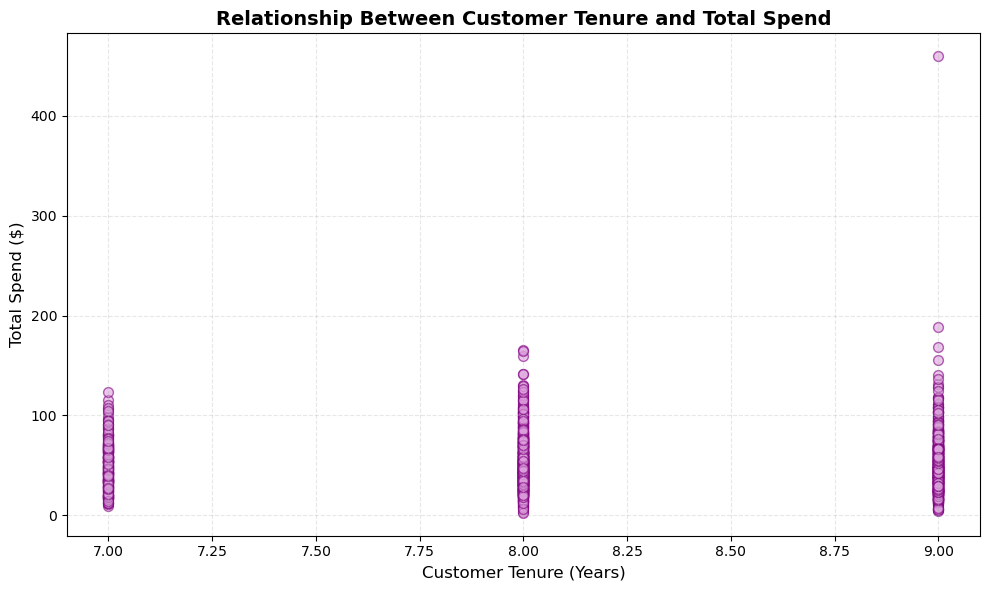

In [171]:
# Do customers who have been customers longer tend to spend more?
from datetime import date
today = date.today()

coffee_df['customer_since'] = pd.to_datetime(coffee_df['customer_since'])
coffee_df['customer_tenure_years'] = (today.year - coffee_df['customer_since'].dt.year)
customer_loyalty_spend = coffee_df.groupby(['customer_id', 'customer_tenure_years'])['line_item_amount'].sum().reset_index()


plt.figure(figsize=(10, 6))
plt.scatter(customer_loyalty_spend['customer_tenure_years'], customer_loyalty_spend['line_item_amount'], 
            color='plum', alpha=0.6, edgecolors='purple', s=50)
plt.title('Relationship Between Customer Tenure and Total Spend', fontsize=14, fontweight='bold')
plt.xlabel('Customer Tenure (Years)', fontsize=12)
plt.ylabel('Total Spend ($)', fontsize=12)
plt.tight_layout()
plt.show()


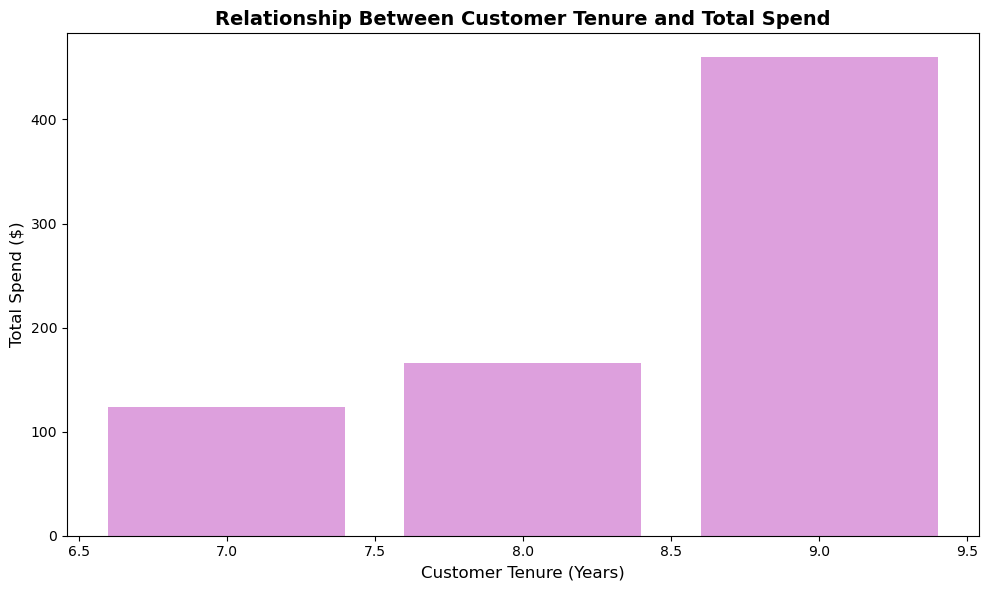

In [173]:

plt.figure(figsize=(10, 6))
plt.bar(customer_loyalty_spend['customer_tenure_years'], customer_loyalty_spend['line_item_amount'], 
            color='plum')
plt.title('Relationship Between Customer Tenure and Total Spend', fontsize=14, fontweight='bold')
plt.xlabel('Customer Tenure (Years)', fontsize=12)
plt.ylabel('Total Spend ($)', fontsize=12)
plt.tight_layout()
plt.show()
